<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [17]:
# Your code here

#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [3]:
# Your code here

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [16]:
# Your code here

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [15]:
# Your code here


## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [ ]:

def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here 

In [ ]:
# Now import the function from myutils

In [ ]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
# Your code here

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [9]:
# Your code here

In [ ]:
# Your code here

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


In [35]:
# Your code here

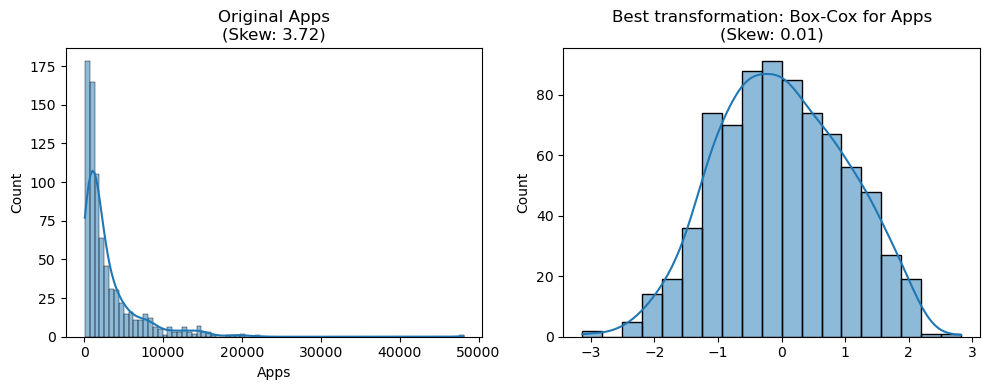

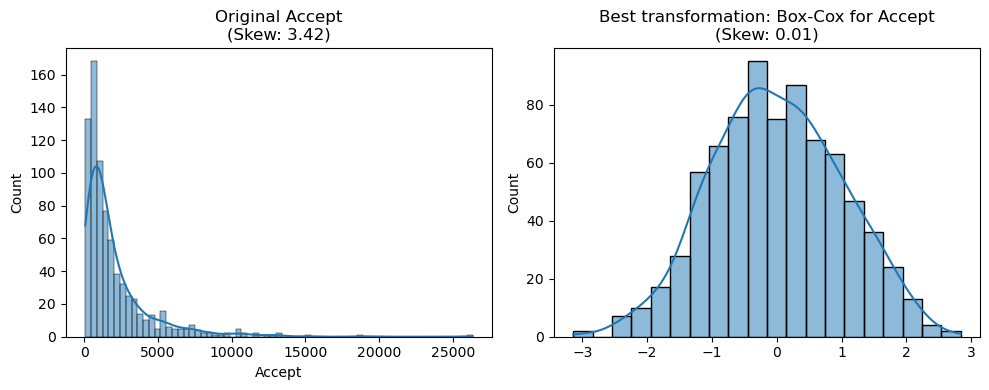

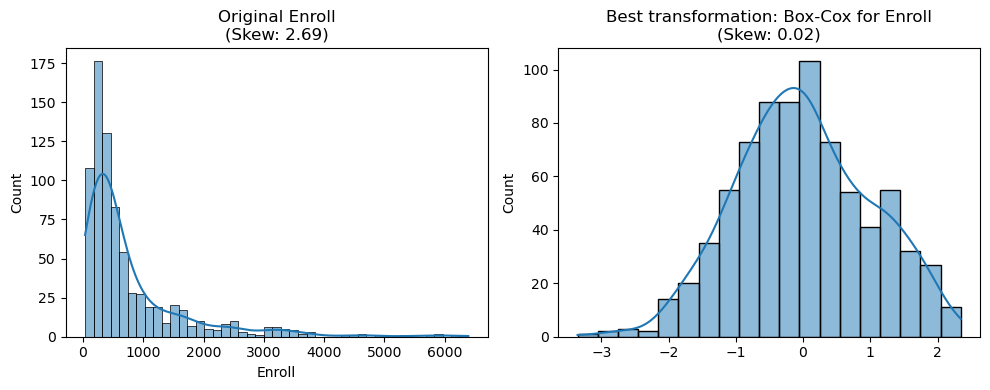

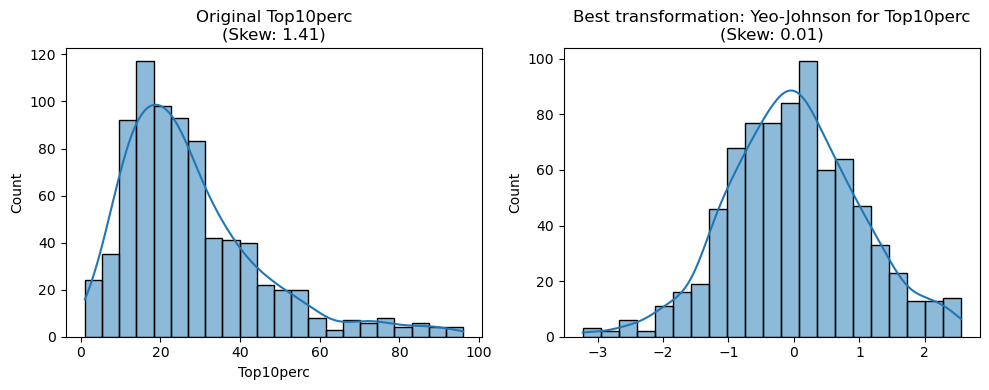

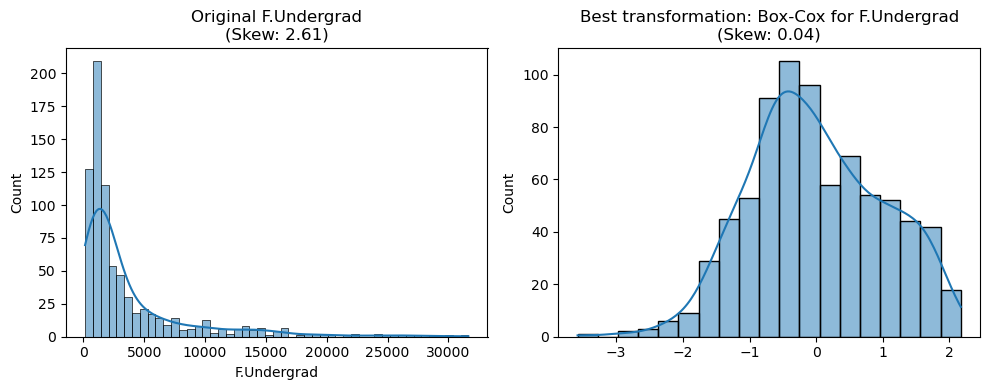

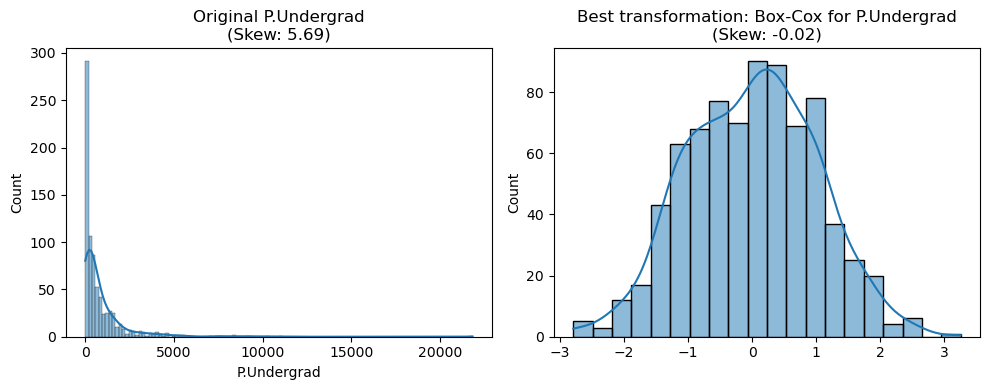

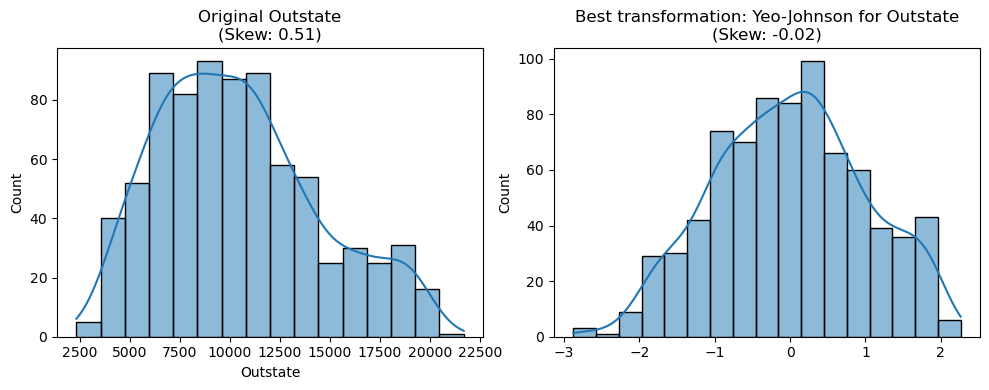

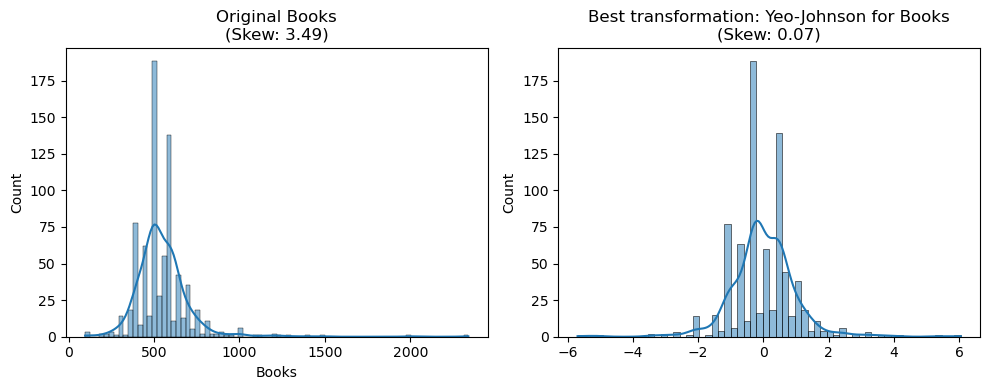

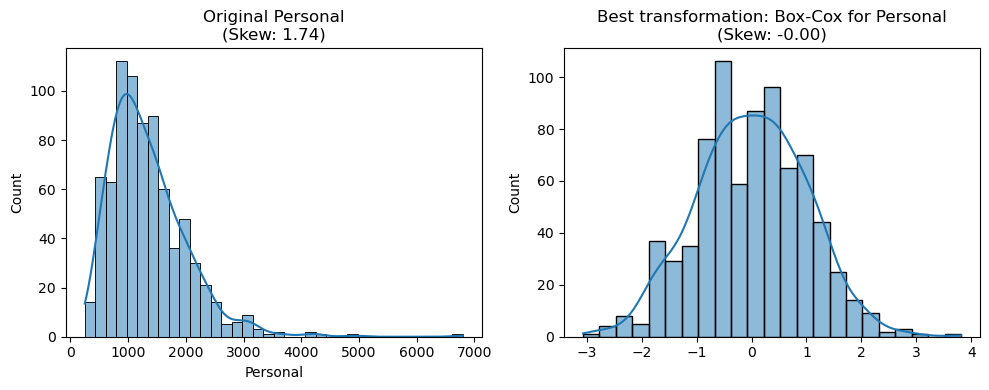

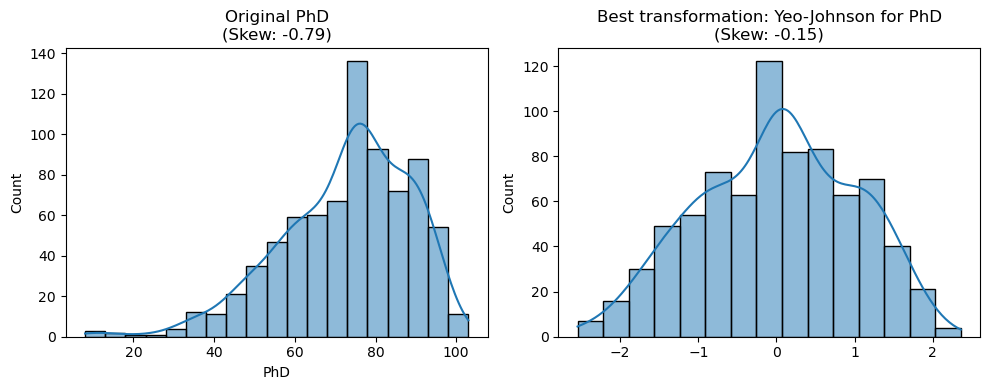

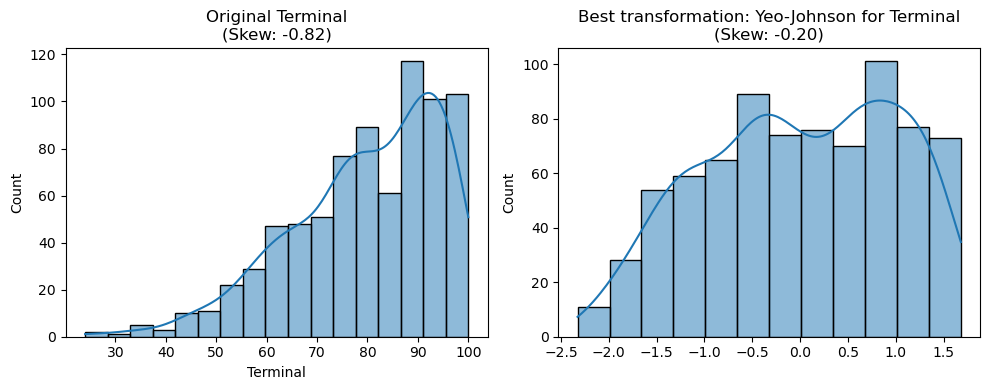

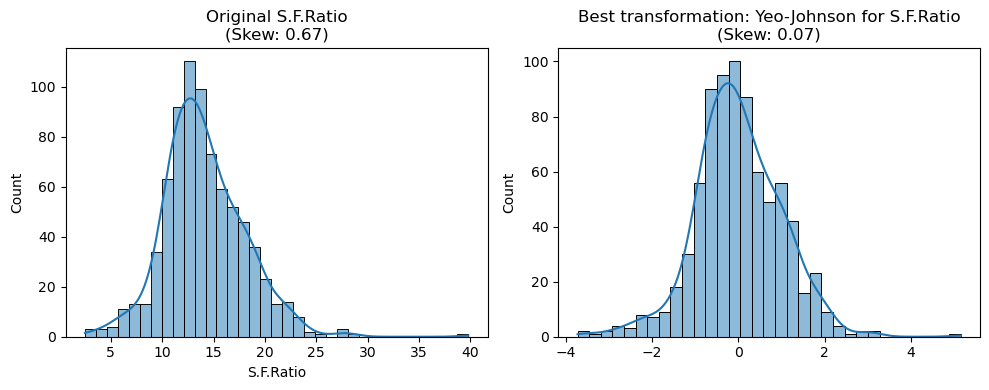

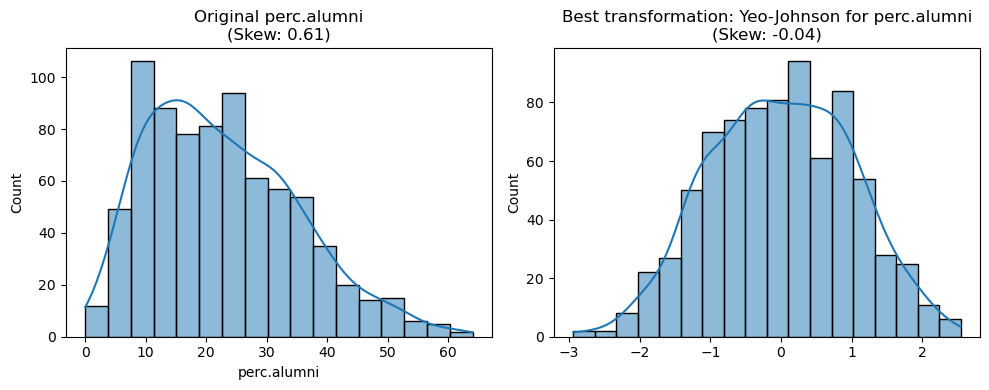

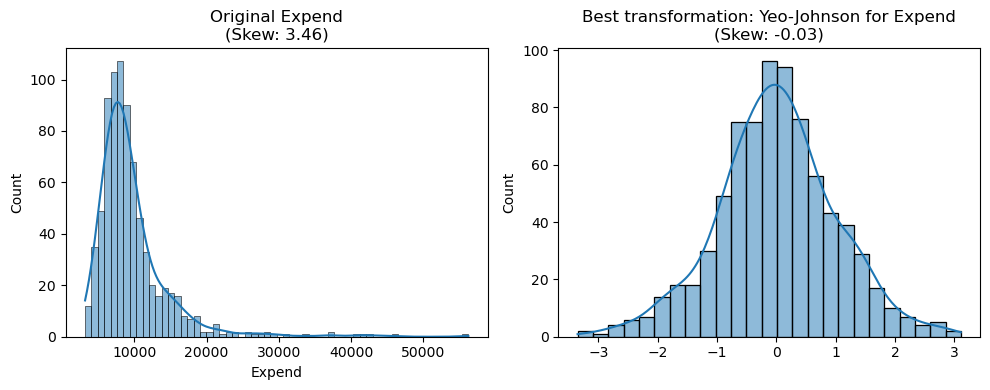

In [ ]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [37]:
trans_cols = []

# Your code here 

## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [38]:
# Your code here 

#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [39]:
# Your code here 

#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [40]:
# Your code here 

#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [41]:
# Your code here 

## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [42]:
cols_to_scale = []

# Your code here 

#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

In [43]:
# Your code here 

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [44]:
# Your code here 

#### 15. Fit a linear regression using the raw predictors


In [45]:
untrans_predictors = []

# Your code here 

#### 16. Fit the same model using the log-transformed predictors

In [46]:
trans_predictors = []

# Your code here 

#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [47]:
# Your code here 

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [48]:
# Your code here 